# Orthotropic Wrapper



This example demonstrates the {ref}`OrthotropicWrapper` material. 

This example is adapted from [this](https://opensees.github.io/OpenSeesDocumentation/user/manual/material/ndMaterials/Orthotropic.html) web page. 

A simple example which evaluates the Yield domain in the plane-stress plane (Szz = 0) of the original isotropic J2Plasticity model (Sy = 400 MPa) and of its orthotropic counter-part (Sx = 1.5*Sy, Ex = 1.5*Ey).

## Modeling

In [ ]:
import math

E = 200000.0
v = 0.3
# Shear modulus
G = E/(2.0*(1.0+v))
# Bulk modulus
K = E/(3.0*(1.0-2.0*v))
# Yield stress
sig0 = 400.0

In [2]:

import xara

base = xara.MultiaxialMaterial("J2Plasticity", K, G, sig0, sig0, 0.0, 0.0)

orth = xara.MultiaxialMaterial("Orthotropic", base, 
                               Ex=E*1.5, Ey=E, Ez=E,
                               Gxy=G, Gyz=G, Gzx=G,
                               vxy=v, vyz=v, vzx=v,
                               Axx=1.0/1.5, Ayy=1.0, Azz=1.0,
                               Axyxy=1.0, Ayzyz=1.0, Axzxz=1.0)


The model uses a {ref}`Triangle <Tri31>` element with a {ref}`PlaneStress <PlaneSection>` section.

In [3]:

def create_patch(material):

    model = xara.Model(ndm=2, ndf=2)

    model.material(base)
    model.material(orth)
    
    section = xara.PlaneSection("PlaneStress", material, 1.0)

    # Add the section to the model
    model.section(section)

    # Create a triangle
    model.node( 1, 0, 0 )
    model.node( 2, 1, 0 )
    model.node( 3, 0, 1 )

    # fixity
    model.fix( 1,   1, 1)
    model.fix( 2,   0, 1)
    model.fix( 3,   1, 0)


    model.element("tri31", 1, (1, 2, 3),  section=section)


    return model

## Analysis

In [4]:

def analyze_dir(dX, dY, material):

    # the 2D model
    model = create_patch(material)

    # a simple ramp
    model.timeSeries("Linear", 1, factor=2.0*sig0 )

    # imposed stresses
    model.pattern( "Plain", 1, 1 )
    model.load( 2, dX, 0.0 )
    model.load( 3, 0.0, dY )

    # analyze
    model.constraints( "Transformation" )
    model.numberer( "Plain" )
    model.system( "FullGeneral" )
    model.test( "NormDispIncr", 1.0e-6, 3, 9)
    model.algorithm( "Newton" )

    dLambda = 0.1
    dLambdaMin = 0.001
    Lambda = 0.0
    sX = 0.0
    sY = 0.0

    while True:
        model.integrator( "LoadControl", dLambda )
        model.analysis("Static")
        ok = model.analyze( 1 )
        if ok == 0:
            stress = model.eleResponse( 1, "material", 1, "stress" )
            sX = stress[0]
            sY = stress[1]
            Lambda += dLambda
            if Lambda > 0.9999:
                break
        else:
            dLambda /= 2.0
            if dLambda < dLambdaMin:
                break

    # done
    return (sX, sY)

In [5]:
def analyze_surface():
    NDiv = 48
    NP = NDiv+1
    dAngle = 2.0*math.pi/NDiv
    SX = [0.0]*NP
    SY = [0.0]*NP
    SXortho = [0.0]*NP
    SYortho = [0.0]*NP
    for i in range(NDiv):
        angle = i*dAngle
        dX = math.cos(angle)
        dY = math.sin(angle)
        iso = analyze_dir(dX, dY, base)
        ortho = analyze_dir(dX, dY, orth)
        SX[i] = iso[0]
        SY[i] = iso[1]
        SXortho[i] = ortho[0]
        SYortho[i] = ortho[1]
    SX[-1] = SX[0]
    SY[-1] = SY[0]
    SXortho[-1] = SXortho[0]
    SYortho[-1] = SYortho[0]

    return (SX, SY, SXortho, SYortho)



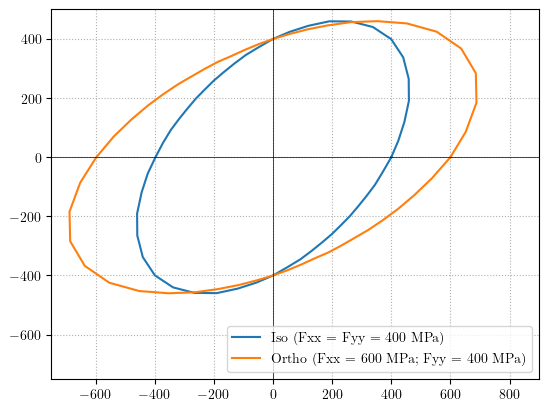

In [6]:

SX, SY, SXortho, SYortho = analyze_surface()

from matplotlib import pyplot as plt
fig, ax = plt.subplots(1,1)
ax.plot(SX, SY, label='Iso (Fxx = Fyy = 400 MPa)')
ax.plot(SXortho, SYortho, label='Ortho (Fxx = 600 MPa; Fyy = 400 MPa)')
ax.grid(linestyle=':')
ax.set_aspect('equal', 'box')
ax.set(xlim=[-750, 900],ylim=[-750, 500])
ax.plot([-1000,1000],[0,0],color='black',linewidth=0.5)
ax.plot([0,0],[-1000,1000],color='black',linewidth=0.5)
ax.legend(loc='lower right');